## Imports

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## Load Data

In [2]:
df=pd.read_csv('Resume.csv')
print(df.shape)
df.head()

(2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


## Feature 1: Years of experience (extracted using regex)

In [3]:
# CELL — Rewrite years_experience with context-aware matching
def extract_years_experience(text):
    text = str(text).lower()
    
    patterns = [
        r'(\d{1,2})\+?\s*(?:years?|yrs?)\s+(?:of\s+)?(?:experience|exp\b)',
        r'(?:experience|exp\b)\s*[:\-]?\s*(\d{1,2})\+?\s*(?:years?|yrs?)',
        r'over\s+(\d{1,2})\+?\s*(?:years?|yrs?)\s+(?:of\s+)?experience',
    ]
    matches = []
    for pattern in patterns:
        matches.extend(re.findall(pattern, text))

    valid = [int(m) for m in matches if int(m) <= 50]
    return max(valid) if valid else 0

df['years_experience'] = df['Resume_str'].apply(extract_years_experience)
df['years_experience'].describe()

count    2484.000000
mean        1.636473
std         5.059562
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        38.000000
Name: years_experience, dtype: float64

## Extract Certification Count

In [4]:
cert_keyword=['certified', 'certification', 'certificate', 'license', 'licensed', 'credential']

def count_cert_mentions(text):
    text=str(text).lower()
    count=0
    for keyword in cert_keyword:
        count+=text.count(keyword)
    return count

df['cert_count']=df['Resume_str'].apply(count_cert_mentions)
df['cert_count'].describe()

count    2484.000000
mean        1.527778
std         2.299826
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        23.000000
Name: cert_count, dtype: float64

## Count instances of a number near an achievement-style verb (increased, reduced, managed, led, saved, grew, improved)

In [5]:
achievement_verbs = ['increased','reduced','improved','managed','led','saved','grew', 'generated', 'achieved', 'delivered', 'decreased', 'boosted']

def count_quantified_achievements(text):
    text = str(text).lower()
    count = 0
    for verb in achievement_verbs:
        pattern = rf'{verb}\b(?:\s+\w+){{0,6}}\s*\d+%?'
        count += len(re.findall(pattern, text))
    return count

df['quantified_achievements'] = df['Resume_str'].apply(count_quantified_achievements)
df['quantified_achievements'].describe()

count    2484.000000
mean        0.642512
std         1.369443
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        20.000000
Name: quantified_achievements, dtype: float64

## Check for presence of standard resume sections

In [6]:
section_headers = ['summary', 'experience', 'education', 'skills', 'certifications','projects', 'achievements', 'objective']

def structural_completeness_score(text):
    text = str(text).lower()
    score = 0
    for header in section_headers:
        if header in text:
            score += 1
    return score

df['structural_completeness_score'] = df['Resume_str'].apply(structural_completeness_score)
df['structural_completeness_score'].describe()

count    2484.000000
mean        4.587762
std         0.937402
min         0.000000
25%         4.000000
50%         5.000000
75%         5.000000
max         8.000000
Name: structural_completeness_score, dtype: float64

## Resume length

In [7]:
df['word_count'] = df['Resume_str'].str.split().str.len()
df['word_count'].describe()

count    2484.000000
mean      811.325684
std       371.006906
min         0.000000
25%       651.000000
50%       757.000000
75%       933.000000
max      5190.000000
Name: word_count, dtype: float64

## Assemble feature matrix and scale

In [8]:
feature_cols = ['years_experience', 'cert_count', 'quantified_achievements','structural_completeness_score', 'word_count']

X = df[feature_cols].copy()
print(X.describe())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

       years_experience   cert_count  quantified_achievements  \
count       2484.000000  2484.000000              2484.000000   
mean           1.636473     1.527778                 0.642512   
std            5.059562     2.299826                 1.369443   
min            0.000000     0.000000                 0.000000   
25%            0.000000     0.000000                 0.000000   
50%            0.000000     1.000000                 0.000000   
75%            0.000000     2.000000                 1.000000   
max           38.000000    23.000000                20.000000   

       structural_completeness_score   word_count  
count                    2484.000000  2484.000000  
mean                        4.587762   811.325684  
std                         0.937402   371.006906  
min                         0.000000     0.000000  
25%                         4.000000   651.000000  
50%                         5.000000   757.000000  
75%                         5.000000   933.000000 

In [9]:
# CELL — Spot check the new extraction
nonzero = df[df['years_experience'] > 0][['Resume_str', 'years_experience']]
print(f"Non-zero matches: {len(nonzero)} out of {len(df)}")

for idx, row in nonzero.sample(min(10, len(nonzero)), random_state=1).iterrows():
    yrs = row['years_experience']
    text = row['Resume_str'].lower()
    match = re.search(r'.{40}(?:experience|exp\b).{20}', text)
    print(f"[{yrs} yrs] ...{match.group() if match else '(context not found)'}...")

Non-zero matches: 313 out of 2484
[8 yrs] ...(context not found)...
[5 yrs] ...er in business i posses over 5 years of experience in various fields a...
[20 yrs] ...d aviation electrician with 20 years of experience on large-scale elec...
[8 yrs] ...nd design for products. but i also have experience in customer service...
[15 yrs] ...   cashier           career overview    experienced receptionist perso...
[20 yrs] ...essional background    over 20 years of experience with a diversified ...
[25 yrs] ...rofessional profile    over 25 years of experience providing technical...
[12 yrs] ...ring manager with more than 12 years of experience in high-volume glob...
[16 yrs] ...tivated civil engineer with 16 years of experience working for one of ...
[5 yrs] ...dicated sales coordinator with 5+ years experience in the sales enviro...


In [10]:
sample_high = df[df['quantified_achievements'] > 3][['Resume_str', 'quantified_achievements']]
print(f"Resumes with >3 quantified achievements: {len(sample_high)}")

for idx, row in sample_high.head(5).iterrows():
    text = row['Resume_str'].lower()
    print(f"\n--- Count: {row['quantified_achievements']} ---")
    for verb in ['increased', 'reduced', 'improved', 'managed', 'led', 'saved',
                 'grew', 'generated', 'achieved', 'delivered', 'decreased', 'boosted']:
        for m in re.finditer(rf'{verb}\b(?:\s+\w+){{0,6}}\s*\d+%?', text):
            print(f"  [{verb}] ...{text[max(0,m.start()-20):m.end()+10]}...")

Resumes with >3 quantified achievements: 102

--- Count: 4 ---
  [reduced] ...ort training, which reduced internal rework by 75% within 90...
  [reduced] ...ocess time by 30%.  reduced turnover from 68% to 14% by...
  [improved] ... searching for it.  improved customer service indicators by 100% plus in 1...
  [saved] ...nomical locations - saved expenses by 40%.  achieve...

--- Count: 6 ---
  [reduced] ...ts.transitioned and reduced 24 shift configurations to 4 by implem...
  [reduced] ... fulfillment team.  reduced errors by 83% using str...
  [reduced] ...ney stream training.reduced absenteeism from 4% to 1.5%.i...
  [managed] ...abor negotiations.  managed 3 direct re...
  [led] ..., ohestablished and led regional safety and health network for 4 dannon us...
  [led] ...and site security.  led site of 400 employees and 200 contracto...

--- Count: 4 ---
  [increased] ...marketing plan that increased clientele by 3% for this ...
  [managed] ...es.  maintained and managed over 100 cl

## Determine k for k-Means via elbow method

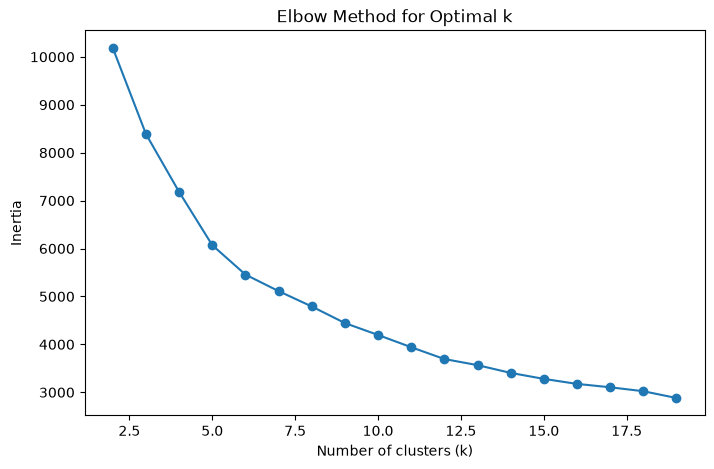

In [11]:
import matplotlib.pyplot as plt
inertias=[]
k_range = range(2,20)
for k in k_range:
    km=KMeans(n_clusters=k, random_state=42,n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

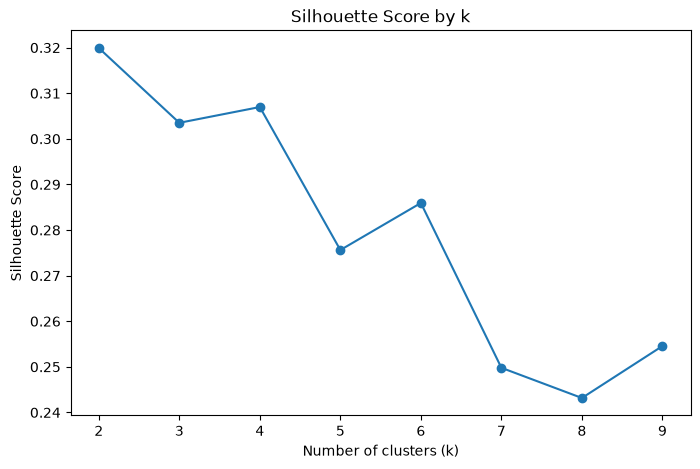

k=2: silhouette=0.3199
k=3: silhouette=0.3035
k=4: silhouette=0.3070
k=5: silhouette=0.2756
k=6: silhouette=0.2859
k=7: silhouette=0.2498
k=8: silhouette=0.2432
k=9: silhouette=0.2546


In [12]:


sil_scores = []
k_range_sil = range(2, 10)
for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(list(k_range_sil), sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.show()

for k, s in zip(k_range_sil, sil_scores):
    print(f"k={k}: silhouette={s:.4f}")

## Run k-Means with chosen k 

In [13]:
k = 3
kmeans=KMeans(n_clusters=k, random_state=42, n_init=10)
df['quality_cluster_kmeans'] = kmeans.fit_predict(X_scaled)
print(df['quality_cluster_kmeans'].value_counts())
print("Silhouette score:", silhouette_score(X_scaled,df['quality_cluster_kmeans']))

quality_cluster_kmeans
0    1542
2     738
1     204
Name: count, dtype: int64
Silhouette score: 0.3035138861339665


## Run DBSCAN as a second, comparison clustering method

In [14]:
dbscan=DBSCAN(eps=1.0, min_samples=10)
df['quality_cluster_dbscan'] = dbscan.fit_predict(X_scaled)

print(df['quality_cluster_dbscan'].value_counts())

quality_cluster_dbscan
 1    901
 0    816
 3    248
-1    247
 2    224
 4     38
 5     10
Name: count, dtype: int64


In [15]:
print(df.groupby('quality_cluster_dbscan')[feature_cols].mean())
print(pd.crosstab(df['quality_cluster_kmeans'], df['quality_cluster_dbscan']))

                        years_experience  cert_count  quantified_achievements  \
quality_cluster_dbscan                                                          
-1                              9.186235    4.149798                 2.072874   
 0                              1.022059    1.341912                 0.502451   
 1                              0.926748    1.035516                 0.455050   
 2                              0.102679    0.830357                 0.410714   
 3                              0.012097    1.814516                 0.620968   
 4                              0.184211    2.657895                 0.421053   
 5                              9.400000    0.500000                 0.200000   

                        structural_completeness_score   word_count  
quality_cluster_dbscan                                              
-1                                           4.963563  1218.404858  
 0                                           5.000000   805.137

## Characterize each k-Means cluster

In [16]:
cluster_summary = df.groupby('quality_cluster_kmeans')[feature_cols].mean()
print(cluster_summary)

                        years_experience  cert_count  quantified_achievements  \
quality_cluster_kmeans                                                          
0                               0.231518    0.710765                 0.378080   
1                              16.852941    1.843137                 0.901961   
2                               0.365854    3.147696                 1.123306   

                        structural_completeness_score   word_count  
quality_cluster_kmeans                                              
0                                            4.181582   690.737354  
1                                            4.705882   914.686275  
2                                            5.403794  1034.715447  


## Visualize clusters in 2D via PCA

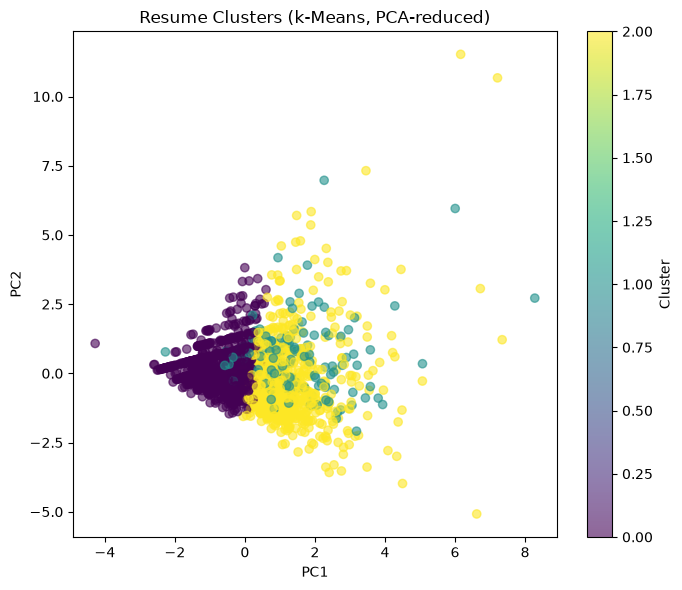

Variance explained by 2 components: 49.79%


In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['quality_cluster_kmeans'], cmap='viridis', alpha=0.6)
plt.title('Resume Clusters (k-Means, PCA-reduced)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

## Export quality clustering results for the team

In [19]:
output_cols = ['ID', 'Category', 'years_experience', 'cert_count','quantified_achievements', 'structural_completeness_score','word_count', 'quality_cluster_kmeans', 'quality_cluster_dbscan']


df[output_cols].to_csv('clustering_results.csv', index=False)
print("Saved clustering_results.csv with", len(df), "rows")

Saved clustering_results.csv with 2484 rows
